In [44]:
# Libraries
import numpy as np
from brainstat.datasets import fetch_mask, fetch_template_surface
from osfclient import OSF
import os
import requests
import tempfile
import glob
import numpy as np
import nibabel as nib
import pandas as pd
import seaborn as sns
import networkx as nx
from scipy.stats import spearmanr
import statsmodels.api as sm

# Load utilities functions from utils.py
from utils import *

In [64]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nib.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nib.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Labels and boolean mask
mask_surf = mask_5k != 0

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

In [34]:
# Load the tval map variable (Generated on the Fig.1 ipynb)
osf_tvals = osf_download("surf-fsLR-32k_desc-tvalues_MixedEffectsModel.npy", project_id='ct3gw')
mk6240_tval_map = np.load(osf_tvals)

# Remove NaN from tmap
mk6240_tval_map[np.isnan(mk6240_tval_map)] = 0

# Resample mk6240 group difference T-val map from fslr32k to fslr5k
mk6240_tval_map_5k = metric_resample(mk6240_tval_map)

Found file: surf-fsLR-32k_desc-tvalues_MixedEffectsModel.npy


100%|█████████████████████████████████████████████| 520k/520k [00:00<00:00, 3.62Mbytes/s]


Downloaded surf-fsLR-32k_desc-tvalues_MixedEffectsModel.npy to /tmp/tmp3xlfcvra/surf-fsLR-32k_desc-tvalues_MixedEffectsModel.npy


In [35]:
T1map_G1 = np.load('/host/verges/tank/data/youngeun/myjupyter/array/T1map_G1_5k.npy')

Spearman correlation (rho): -0.293, p-value: 3.783e-175


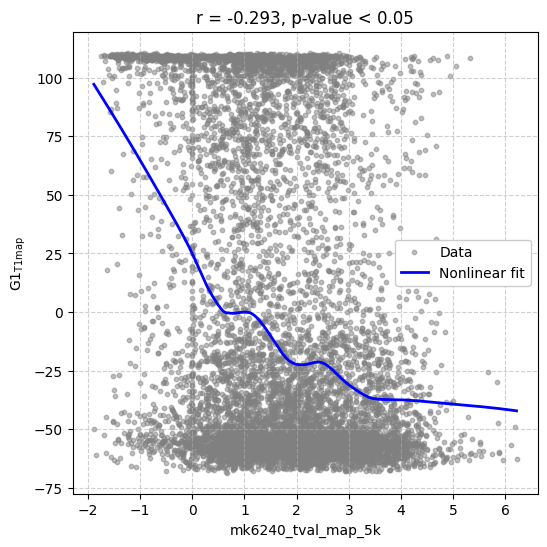

In [62]:
mask = ~np.isnan(mk6240_tval_map_5k) & ~np.isnan(T1map_G1)
x_clean = mk6240_tval_map_5k[mask]
y_clean = T1map_G1[mask]

rho, pval = spearmanr(x_clean, y_clean)
print(f"Spearman correlation (rho): {rho:.3f}, p-value: {pval:.3e}")

# p-value 포맷팅 (0.05 기준)
if pval < 0.05:
    p_text = "p-value < 0.05"
else:
    p_text = f"p = {pval:.3f}"

# 산점도
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, alpha=0.5, s=10, label="Data", color="grey")

# LOWESS 곡선 추가
lowess = sm.nonparametric.lowess
z = lowess(y_clean, x_clean, frac=0.3)  # frac=부드러움 정도 (0.2~0.4 조절 가능)
plt.plot(z[:, 0], z[:, 1], color="blue", linewidth=2, label="Nonlinear fit")

plt.xlabel("mk6240_tval_map_5k")
plt.ylabel(r"${\text{G1}}$$_{\text{T1map}}$")
plt.title(f"r = {rho:.3f}, {p_text}")
plt.legend(framealpha=1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

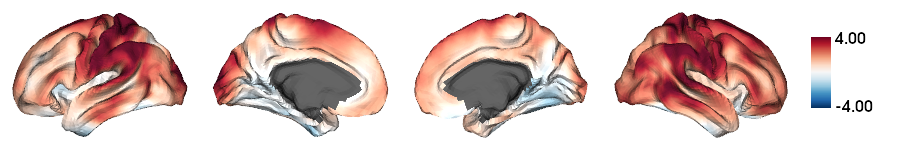

In [82]:
Ngrad=1
mk6240_tval_map_5k[mask_5k==False] = np.nan
plot_hemispheres(f5k_lh, f5k_rh, array_name=mk6240_tval_map_5k, cmap='RdBu_r', nan_color=(0.3, 0.3, 0.3, 1),
  zoom=1.5, size=(900, 150*Ngrad), embed_nb=True,color_range=(-4,4),
  color_bar='right', screenshot=False)